## Data loading, inspection and hypotheses testing

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency

sns.set_theme(style="whitegrid")

## Loading dataset

In [47]:
df = pd.read_csv(r'C:\Users\wwwsu\Documents\Customer-Churn-Project-\data\processed_churn.csv')
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [48]:
df.shape

(7032, 20)

In [49]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   str    
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   str    
 3   Dependents        7032 non-null   str    
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   str    
 6   MultipleLines     7032 non-null   str    
 7   InternetService   7032 non-null   str    
 8   OnlineSecurity    7032 non-null   str    
 9   OnlineBackup      7032 non-null   str    
 10  DeviceProtection  7032 non-null   str    
 11  TechSupport       7032 non-null   str    
 12  StreamingTV       7032 non-null   str    
 13  StreamingMovies   7032 non-null   str    
 14  Contract          7032 non-null   str    
 15  PaperlessBilling  7032 non-null   str    
 16  PaymentMethod     7032 non-null   str    
 17  Monthl

In [50]:
df.describe(include='all')

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7032,7032.000000,7032,7032,7032.000000,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032.000000,7032.000000,7032.000000
unique,2,NaN,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,NaN,NaN
top,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,NaN,NaN
freq,3549,NaN,3639,4933,NaN,6352,3385,3096,3497,3087,3094,3472,2809,2781,3875,4168,2365,NaN,NaN,NaN
mean,NaN,0.162400,NaN,NaN,32.421786,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.798208,2283.300441,0.265785
std,NaN,0.368844,NaN,NaN,24.545260,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.085974,2266.771362,0.441782
min,NaN,0.000000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,18.800000,0.000000
25%,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.587500,401.450000,0.000000
50%,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,1397.475000,0.000000
75%,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.862500,3794.737500,1.000000


### Churn Distribution

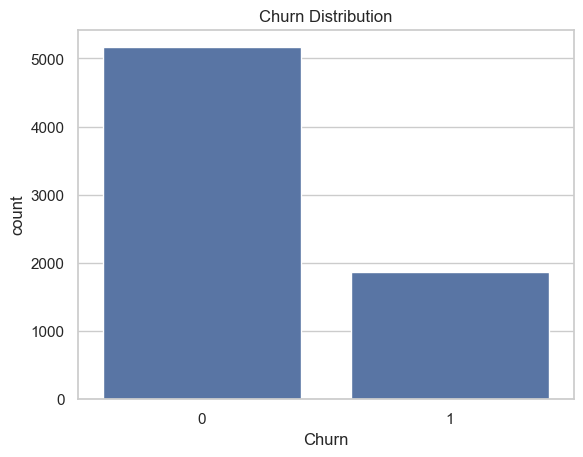

Churn
0    73.421502
1    26.578498
Name: proportion, dtype: float64


In [51]:
# Identifying target variable distribution
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

print(df["Churn"].value_counts(normalize=True)*100)

Churn is more than 20 percent here so it can be assumed to be a realistic retention problem.

### Categorising variables 

In [34]:
demographic = ["gender", "SeniorCitizen", "Partner", "Dependents"]

contractual = ["Contract", "tenure"]

financial = ["MonthlyCharges", "TotalCharges" , "PaperlessBilling", "PaymentMethod"]

behavioral = [
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

In [35]:
print("Demographic:", demographic)
print("Contractual:", contractual)
print("Financial:", financial)
print("Behavioral:", behavioral)

Demographic: ['gender', 'SeniorCitizen', 'Partner', 'Dependents']
Contractual: ['Contract', 'tenure']
Financial: ['MonthlyCharges', 'TotalCharges', 'PaperlessBilling', 'PaymentMethod']
Behavioral: ['InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']


## Hypothesis 1: Contract vs Churn

First hypothesis states:
* Null hypothesis (H₀): Contract type and churn are independent.

* Alternative hypothesis (H₁): Contract type and churn are associated.

In [52]:
# Computing churn rate by contract
df.groupby("Contract")["Churn"].mean().sort_values(ascending=False)

Contract
Month-to-month    0.427097
One year          0.112772
Two year          0.028487
Name: Churn, dtype: float64

In [53]:
contract_churn = df.groupby("Contract")["Churn"].mean()*100
contract_churn

Contract
Month-to-month    42.709677
One year          11.277174
Two year           2.848665
Name: Churn, dtype: float64

Customers without long-term commitment churn 15x more than those on 2-year contracts.

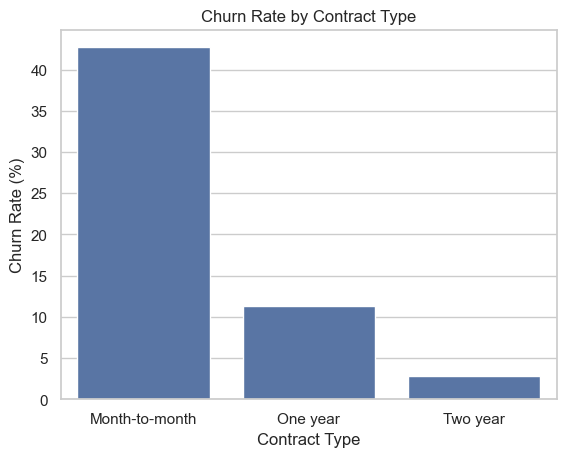

In [54]:
# Visualizing churn rate by contract
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x=contract_churn.index, y=contract_churn.values)
plt.ylabel("Churn Rate (%)")
plt.xlabel("Contract Type")
plt.title("Churn Rate by Contract Type")
plt.show()

* Churn rates decline sharply with increasing contract duration.
* Customers on month-to-month contracts exhibit significantly higher attrition risk than those on longer contracts.
* This supports the hypothesis that contractual commitment reduces churn by increasing switching costs and behavioral lock-in.

### Statistical test for Contract vs Churn

In [55]:
from scipy.stats import chi2_contingency

contract_table = pd.crosstab(df["Contract"], df["Churn"])

chi2, p, dof, expected = chi2_contingency(contract_table)

print("Chi-square:", chi2)
print("p-value:", p)

Chi-square: 1179.5458287339445
p-value: 7.326182186265472e-257


In [25]:
if p < 0.05:
    print("Result: Contract type significantly affects churn")
else:
    print("Result: No statistically significant relationship")

Result: Contract type significantly affects churn


#### Conclusion
The chi-square test shows a statistically significant relationship between contract type and churn (p < 0.05). Therefore, we reject the null hypothesis and conclude that contract type influences customer churn. Customers on month-to-month contracts are more likely to churn compared to those on long-term contracts.

### Hypothesis 2: Payment Method vs Churn

Second hypothesis states:
* Null hypothesis (H₀): Payment method and churn are independent.

* Alternative hypothesis (H₁): Payment method and churn are associated.

In [56]:
payment_churn = df.groupby("PaymentMethod")["Churn"].mean()*100
payment_churn.sort_values(ascending=False)

PaymentMethod
Electronic check             45.285412
Mailed check                 19.201995
Bank transfer (automatic)    16.731518
Credit card (automatic)      15.253123
Name: Churn, dtype: float64

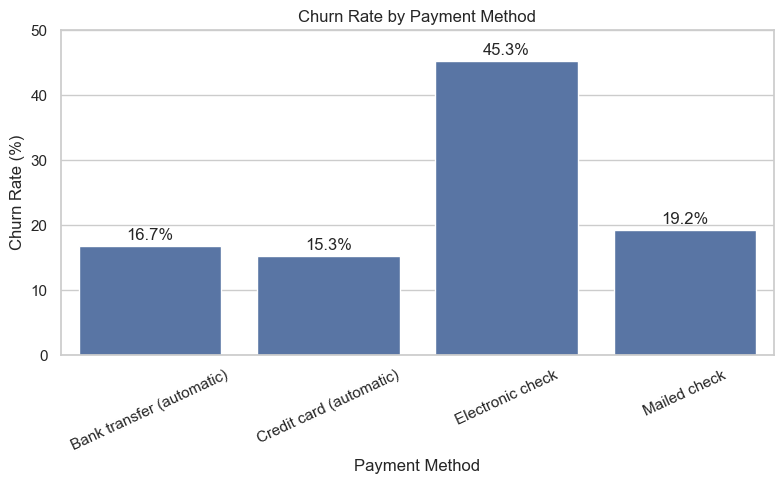

In [57]:
# Visualizing churn rate by payment method
plt.figure(figsize=(8,5))

sns.barplot(
    x=payment_churn.index,
    y=payment_churn.values
)

plt.ylabel("Churn Rate (%)")
plt.xlabel("Payment Method")
plt.title("Churn Rate by Payment Method")
plt.xticks(rotation=25)
plt.ylim(0, 50)

# add value labels on bars
for i, v in enumerate(payment_churn.values):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center')

plt.tight_layout()
plt.show()

* Customers using manual or semi-manual payment methods, particularly electronic checks, exhibit substantially higher churn rates than those using automated payments.
* This suggests that automated billing creates behavioral lock-in, reducing churn by lowering the cognitive and transactional effort required to remain subscribed.

### Statistical test for Payment Method vs Churn

In [58]:
payment_table = pd.crosstab(df["PaymentMethod"], df["Churn"])

chi2, p, dof, expected = chi2_contingency(payment_table)

print("Chi-square:", chi2)
print("p-value:", p)

Chi-square: 645.4299001234638
p-value: 1.4263098511063342e-139


In [59]:
if p < 0.05:
    print("Result: Payment method significantly affects churn")
else:
    print("Result: No statistically significant relationship")

Result: Payment method significantly affects churn


#### Conclusion
The chi-square test indicates a statistically significant association between payment method and churn (p < 0.05). Thus, we reject the null hypothesis and conclude that payment method affects churn. Customers using electronic checks show higher churn compared to other payment methods.